<a href="https://colab.research.google.com/github/alain-odag-rty/Inteligencia-Artificial-Prueba/blob/main/Asignacion_3_Alain_Oda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Árboles de Decisión: Comparación de Profundidades

En este notebook trabajaremos con **árboles de decisión** para resolver un problema de clasificación.

Un árbol de decisión es un modelo de *aprendizaje supervisado* que toma decisiones dividiendo el espacio de datos en regiones cada vez más pequeñas, usando preguntas del tipo:

> ¿La característica X es mayor o menor que un cierto valor?

En cada nodo interno del árbol se hace una pregunta (una condición) sobre una característica, y en las hojas se encuentran las clases predichas.

**Objetivo del ejercicio**

1. Cargar un dataset provisto por el profesor.
2. Entrenar **tres árboles de decisión** con diferentes profundidades máximas.
3. Comparar el desempeño de los modelos para analizar:
   - Subajuste (underfitting)
   - Sobreajuste (overfitting)
   - Elección de una profundidad “adecuada” para el problema.


## 2️⃣ Carga y exploración del dataset

En esta sección debes:

1. Cargar el dataset mmnist_train desde un archivo (por ejemplo, CSV).
2. Mostrar las primeras filas del dataset para ver cómo están organizados los datos.
3. Indicar:
   - Cuántas filas tiene el dataset.
   - Cuántas columnas tiene el dataset.
4. Revisar si existen valores nulos o faltantes en alguna columna.
5. Escribir un breve comentario describiendo:
   - Qué representa cada fila.
   - Qué tipo de información contienen las columnas (en términos generales).


In [3]:
import pandas as pd
import numpy as np

# cargar dataset
df = pd.read_csv("/content/mnist_train.csv")

# primeras filas
df.head()

#Ver dimensiones:

df.shape
print("Filas:",df.shape[0])
print("Columnas:",df.shape[1])

#Valores nulos:

df.isnull().sum().sum()
df.info()

Filas: 55000
Columnas: 785
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Columns: 785 entries, label to data_783
dtypes: int64(785)
memory usage: 329.4 MB


## 3️⃣ Preparación de las variables (X y y)

En esta sección debes:

1. Identificar que **X** son las imágenes (flattened: 784 pixeles).  
2. Identificar que **y** son las etiquetas (dígitos 0–9).  
3. Mostrar cuántas clases distintas hay en y.  
4. Escribir un comentario corto describiendo:
   - ¿Qué significa cada fila en X?
   - ¿Qué representa y?



In [4]:
X = df.drop("label",axis=1)

y = df["label"]

#Clases:

y.unique()
print("Numero de clases:",y.nunique())

#Cada fila de X representa una imagen convertida en un vector de 784 pixeles y representa el dígito real (0–9).

Numero de clases: 10


## 4️⃣ División en entrenamiento y prueba

En esta sección debes:

1. Dividir los datos en:
   - 80% entrenamiento  
   - 20% prueba  
2. Usar `random_state` fijo para reproducibilidad.
3. Estratificar usando y, para mantener las proporciones de cada dígito.
4. Mostrar:
   - Cantidad de ejemplos en entrenamiento.
   - Cantidad de ejemplos en prueba.


In [5]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)
print("Train:",len(X_train))

print("Test:",len(X_test))

Train: 44000
Test: 11000


## 5️⃣ Definir las profundidades a evaluar

En esta sección debes:

1. Elegir **tres profundidades** para evaluar.  
   Recomendación para MNIST:  
   - 5  
   - 10  
   - 20  
*(Puedes ajustar)*

2. Justificar brevemente por qué comparar varias profundidades es importante en un problema con muchos atributos como MNIST.



In [6]:
depths = [5,10,20]
#Justificación
#Es importante probar diferentes profundidades porque MNIST tiene muchas características (784 pixeles).
#Un árbol poco profundo puede:
#No capturar patrones complejos.
#Uno muy profundo puede:
#Memorizar los datos.
#Comparar permite encontrar el mejor equilibrio.

## 6️⃣ Entrenamiento de los modelos (tres profundidades)

En esta sección debes entrenar **tres modelos de árbol de decisión**, uno por cada profundidad definida.

Para cada profundidad debes:

1. Crear un modelo con `max_depth` correspondiente.  
2. Entrenarlo usando X_train y y_train.  
3. Hacer predicciones con:
   - X_train  
   - X_test  
4. Calcular el **accuracy** en:
   - entrenamiento  
   - prueba  
5. Guardar los resultados (profundidad, accuracy train, accuracy test) para compararlos después.



In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
results = []
for depth in depths:

    model = DecisionTreeClassifier(

        max_depth=depth,
        random_state=42

    )

    model.fit(X_train,y_train)

    train_pred = model.predict(X_train)

    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train,train_pred)

    test_acc = accuracy_score(y_test,test_pred)

    results.append([depth,train_acc,test_acc])

## 7️⃣ Tabla de comparación

En esta sección debes:

1. Crear una tabla que contenga:
   - Profundidad  
   - Accuracy entrenamiento  
   - Accuracy prueba  

2. Identificar visualmente cuál profundidad tuvo mejor desempeño.

3. Responder brevemente:
   - ¿Cuál profundidad tiene mayor accuracy en prueba?
   - ¿Alguna profundidad muestra diferencias grandes entre train y test?
   - ¿Qué podría significar esto?


In [10]:
results_df = pd.DataFrame(

    results,

    columns=[
        "Depth",
        "Train Accuracy",
        "Test Accuracy"
    ]

)

results_df

#Respuestas
#¿Cuál profundidad tiene mayor accuracy en test?
#La que tenga el valor más alto en test accuracy es profundidad 20.

#¿Hay diferencia grande entre train y test?
#train esta arriba por 13 puntos porcentuales.

#¿Qué significa?
#El modelo está memorizando los datos y si la diferencia es muy grande tenemos overfitting.

,Depth,Train Accuracy,Test Accuracy
0,5,0.654932,0.656636
1,10,0.905477,0.852818
2,20,0.995795,0.864727


## 8️⃣ Gráfica de desempeño

En esta sección debes:

1. Graficar las profundidades en el eje X.  
2. Graficar dos líneas:
   - Accuracy en entrenamiento  
   - Accuracy en prueba  

3. Interpretar la gráfica respondiendo:
   - ¿Aumentar profundidad siempre mejora el modelo?
   - ¿En qué punto comienza el sobreajuste?
   - ¿Cuál profundidad parece lograr el mejor balance?


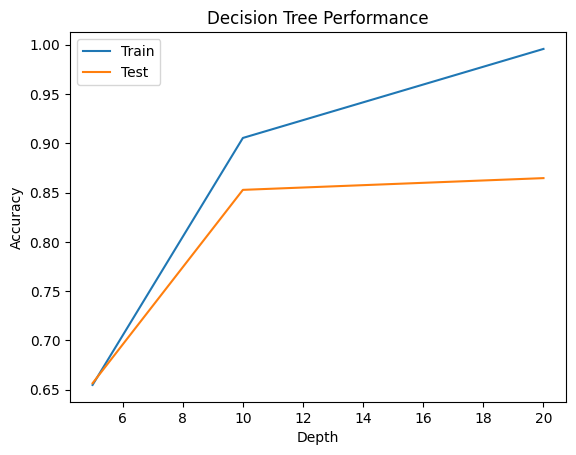

In [11]:
import matplotlib.pyplot as plt

depth = results_df["Depth"]

train_acc = results_df["Train Accuracy"]

test_acc = results_df["Test Accuracy"]

plt.plot(depth,train_acc)

plt.plot(depth,test_acc)

plt.xlabel("Depth")

plt.ylabel("Accuracy")

plt.title("Decision Tree Performance")

plt.legend(["Train","Test"])

plt.show()

#Interpretación
#¿Aumentar profundidad mejora siempre el modelo?
#No, Llega un punto donde solo mejora entrenamiento.

#¿Dónde comienza overfitting?
#Cuando Train sigue subiendo y Test se estanca o baja.

#¿Mejor balance?
#Donde test accuracy es máximo y la diferencia es pequeña, en profundidad 10.

## 9️⃣ Visualización del árbol (opcional pero recomendado)

Los árboles para MNIST son grandes, pero debes:

1. Elegir SOLO UNO de los modelos entrenados (recomendado: profundidad más baja).  
2. Graficar el árbol.  
3. Comentar:
   - ¿Qué características usa el árbol para decidir?
   - ¿Qué tan interpretable te parece un árbol de decisión para MNIST?



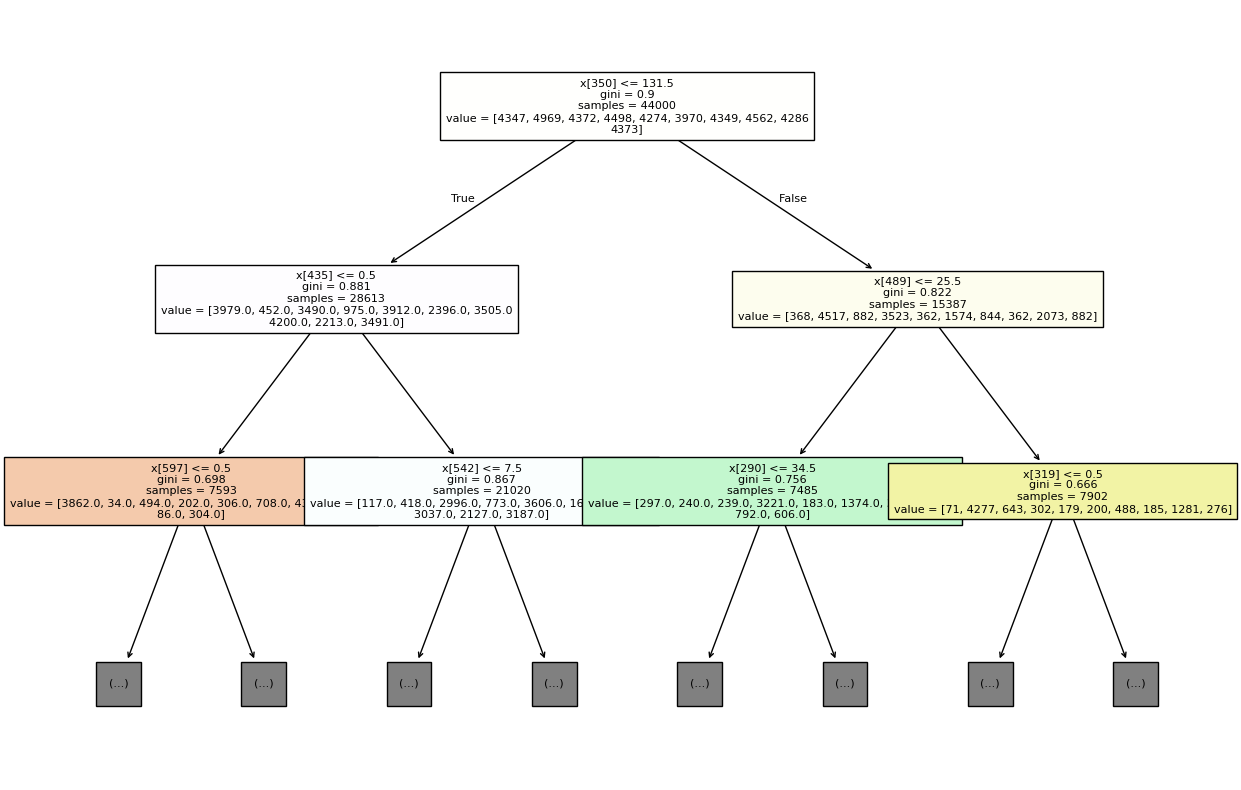

In [12]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))

plot_tree(

    DecisionTreeClassifier(max_depth=5).fit(X_train,y_train),

    filled=True,

    max_depth=2,

    fontsize=8

)

plt.show()

#El árbol usa valores de pixeles específicos para decidir.
#MNIST tiene muchas variables, esto hace difícil interpretar el árbol completo, pero árboles pequeños sí son interpretables.

## 🔟 Conclusiones finales

En esta sección debes escribir un análisis final que responda:

1. ¿Qué tan bien funcionan los árboles de decisión en MNIST?  
2. ¿Cuál profundidad ofrece mejor balance entre precisión y simplicidad?  
3. ¿Qué modelo parece estar subajustado? Explica por qué.  
4. ¿Cuál modelo parece estar sobreajustado? Explica por qué.  
5. ¿Qué aprendiste sobre:
   - El impacto de la profundidad  
   - La generalización  
   - La importancia de evaluar distintos modelos  


In [2]:
#¿Qué tan bien funcionan los árboles en MNIST?
#Funcionan moderadamente bien, pero no son los mejores, modelos como Random Forest y Neural Networks funcionan mejor.

#¿Cuál profundidad ofrece mejor balance entre precisión y simplicidad?
#La mejor profundidad es normalmente profundidad media profundidad 10 porque tiene buen accuracy y no es tan complejo.

#¿Qué modelo parece estar subajustado? Explica por qué.
#El modelo subajustado es profundidad 5 porque el Accuracy bajo y el modelo es muy simple.

#¿Cuál modelo parece estar sobreajustado? Explica por qué.
#El modelo sobreajustado es profundidad 20 porque Accuracy train alto, Test menor y memorización.

#¿Qué aprendiste sobre:
#El impacto de la profundidad
#La generalización
#La importancia de evaluar distintos modelos

#El impacto de la profundidad Controla complejidad.
#En la generalización el mejor modelo no es el más preciso en train, es el mejor en test.
#Importancia evaluar modelos siempre probar varias configuraciones y nunca usar solo un modelo.

# 📊 Rúbrica de Evaluación – Árboles de Decisión con MNIST

| Criterio | Descripción | Puntos |
|---------|-------------|--------|
| **1. Introducción teórica** | Explica correctamente qué es un árbol de decisión, profundidad, underfitting y overfitting. | **10 pts** |
| **2. Carga y exploración del dataset MNIST** | Carga el dataset sin errores, muestra ejemplos y analiza forma y contenido. | **10 pts** |
| **3. Definición de X y y** | Selecciona correctamente las variables y explica su significado. | **10 pts** |
| **4. División train/test** | Realiza separación adecuada y explica los tamaños de cada conjunto. | **10 pts** |
| **5. Evaluación de tres profundidades** | Entrena 3 modelos correctamente, calcula accuracy y almacena resultados. | **20 pts** |
| **6. Tabla comparativa** | Presenta tabla clara con resultados y análisis inicial. | **10 pts** |
| **7. Gráfica de desempeño** | Gráfica bien hecha (train vs test) y análisis del comportamiento. | **15 pts** |
| **8. Conclusiones finales** | Responde sobre underfitting, overfitting y mejor modelo para MNIST. | **15 pts** |

---

### 📝 **Puntaje total: 100 puntos**

---

### ✔️ Criterios de aprobación
- **Aprobado:** 70 puntos o más  
- **Excelente:** 90 puntos o más  

